# Impacto do Recorte de 150 Palavras — TREC 2007

In [1]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score
)

warnings.filterwarnings('ignore')

# --------------- Caminhos ---------------
BASE_DIR    = Path().resolve().parent.parent
DATA_DIR    = BASE_DIR / 'data'
MODELS_DIR  = BASE_DIR / 'models'
TREC_DIR    = MODELS_DIR / 'trec'
FIGURES_DIR = BASE_DIR / 'figures' / 'conclusions'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# --------------- Paleta ---------------
NAVY   = '#1C2B4A'
TEAL   = '#0891B2'
RED    = '#DC2626'
ORANGE = '#F59E0B'
GRAY   = '#64748B'

# --------------- Stopwords e funções ---------------
STOP_WORDS = set(stopwords.words('english'))

def truncate_to_n_words(text, n):
    """Recorta o texto para no máximo n palavras."""
    words = str(text).split()
    return ' '.join(words[:n])

def preprocess(text):
    """Pré-processamento padrão: lowercase, remoção de caracteres
    especiais, remoção de stopwords, tokenização."""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 1]
    return ' '.join(tokens)

def full_pipeline(text, truncate=True, max_words=150):
    """Pipeline completo de pré-processamento com flag de truncagem."""
    if truncate:
        text = truncate_to_n_words(text, max_words)
    return preprocess(text)

print(f'Projeto: {BASE_DIR}')
print(f'Figuras: {FIGURES_DIR}')
print('Imports e funções carregados com sucesso.')

/tmp/ipykernel_17317/2238526553.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Projeto: /home/edson-luiz/Projetos/TCC
Figuras: /home/edson-luiz/Projetos/TCC/figures/conclusions
Imports e funções carregados com sucesso.


In [2]:
# ============================================================
# Treinar modelos SEM truncagem (texto integral)
# ============================================================

# --- Carregar dados brutos ---
TREC_CSV = DATA_DIR / 'trec_2007.csv'
df_raw = pd.read_csv(TREC_CSV, encoding='latin-1', on_bad_lines='skip')

# Detectar colunas
TEXT_CANDIDATES  = ['body', 'message', 'text', 'email', 'content', 'mail']
LABEL_CANDIDATES = ['label', 'spam', 'class', 'category', 'spam/ham', 'type', 'tag']
cols_lower = {c.lower(): c for c in df_raw.columns}
text_col  = next((cols_lower[c] for c in TEXT_CANDIDATES  if c in cols_lower), None)
label_col = next((cols_lower[c] for c in LABEL_CANDIDATES if c in cols_lower), None)

print(f'Dataset: {len(df_raw):,} linhas')
print(f'Coluna de texto : "{text_col}"')
print(f'Coluna de rótulo: "{label_col}"')

# --- Preparar DataFrame ---
df = df_raw[[text_col, label_col]].copy()
df = df.dropna(subset=[text_col])

# Mapear rótulos
valores_unicos = df[label_col].dropna().unique()
label_map = {}
for v in valores_unicos:
    v_lower = str(v).strip().lower()
    if v_lower in ('spam', '1', 'yes', 'true', 's'):
        label_map[v] = 1
    elif v_lower in ('ham', '0', 'no', 'false', 'h', 'legitimate'):
        label_map[v] = 0

df['label'] = df[label_col].map(label_map)
df = df[df['label'].notna()]
df['label'] = df['label'].astype(int)

# --- Pré-processamento SEM truncagem ---
print('\nAplicando pré-processamento SEM truncagem (texto integral)...')
print('Isso pode levar vários minutos para 73k e-mails completos...')
df['text_full'] = df[text_col].apply(lambda x: full_pipeline(x, truncate=False))

# Remover textos vazios
antes = len(df)
df = df[df['text_full'].str.strip() != '']
print(f'Removidos {antes - len(df)} e-mails vazios. Restam: {len(df):,}')

# --- Split ---
X = df['text_full']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\nTreino: {len(X_train):,}  |  Teste: {len(X_test):,}')

# --- TF-IDF ---
tfidf_full = TfidfVectorizer(
    max_features=10000, sublinear_tf=True, min_df=2, ngram_range=(1, 2)
)
X_train_tfidf = tfidf_full.fit_transform(X_train)
X_test_tfidf  = tfidf_full.transform(X_test)
print(f'TF-IDF shape: {X_train_tfidf.shape}')

# --- Treinar modelos e coletar métricas ---
models_config = {
    'Naive Bayes':         MultinomialNB(),
    'SVM':                 LinearSVC(random_state=42, max_iter=2000, dual='auto'),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Regressão Logística': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
}

results_full = []
for name, model in models_config.items():
    print(f'Treinando (sem truncagem): {name}...')
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    results_full.append({
        'Algoritmo': name,
        'Acurácia':  accuracy_score(y_test, y_pred),
        'Precisão':  precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        'Recall':    recall_score(y_test, y_pred, pos_label=1, zero_division=0),
        'F1-score':  f1_score(y_test, y_pred, pos_label=1, zero_division=0),
    })

df_full = pd.DataFrame(results_full).set_index('Algoritmo')
df_full = df_full.sort_values('F1-score', ascending=False)

print('\n' + '=' * 65)
print('RESULTADOS SEM TRUNCAGEM (TEXTO INTEGRAL) — TREC 2007')
print('=' * 65)
print(df_full.round(4).to_string())
print('=' * 65)

Dataset: 75,419 linhas
Coluna de texto : "message"
Coluna de rótulo: "label"

Aplicando pré-processamento SEM truncagem (texto integral)...
Isso pode levar vários minutos para 73k e-mails completos...


Removidos 121 e-mails vazios. Restam: 73,811

Treino: 59,048  |  Teste: 14,763


TF-IDF shape: (59048, 10000)
Treinando (sem truncagem): Naive Bayes...
Treinando (sem truncagem): SVM...


Treinando (sem truncagem): Random Forest...


Treinando (sem truncagem): Regressão Logística...



RESULTADOS SEM TRUNCAGEM (TEXTO INTEGRAL) — TREC 2007
                     Acurácia  Precisão  Recall  F1-score
Algoritmo                                                
Random Forest          0.9949    0.9956  0.9967    0.9961
SVM                    0.9948    0.9948  0.9973    0.9960
Regressão Logística    0.9926    0.9917  0.9971    0.9944
Naive Bayes            0.9525    0.9971  0.9305    0.9627


In [3]:
# ============================================================
# Carregar resultados COM truncagem (150 palavras) já existentes
# ============================================================

df_trunc = pd.read_csv(TREC_DIR / 'results.csv', index_col='Algoritmo')
df_trunc = df_trunc.sort_values('F1-score', ascending=False)

print('=' * 65)
print('RESULTADOS COM TRUNCAGEM (150 PALAVRAS) — TREC 2007')
print('=' * 65)
print(df_trunc.round(4).to_string())
print('=' * 65)

RESULTADOS COM TRUNCAGEM (150 PALAVRAS) — TREC 2007
                     Acurácia  Precisão  Recall  F1-score
Algoritmo                                                
Random Forest          0.9930    0.9932  0.9962    0.9947
SVM                    0.9927    0.9932  0.9957    0.9944
Regressão Logística    0.9894    0.9888  0.9951    0.9919
Naive Bayes            0.9528    0.9948  0.9331    0.9630


In [4]:
# ============================================================
# Tabela comparativa: Com Truncagem vs Sem Truncagem + Delta
# ============================================================

metrics = ['Acurácia', 'Precisão', 'Recall', 'F1-score']

# Garantir mesma ordem de algoritmos
algos = df_trunc.index.tolist()

rows = []
for algo in algos:
    row = {'Algoritmo': algo}
    for m in metrics:
        val_trunc = df_trunc.loc[algo, m]
        val_full  = df_full.loc[algo, m]
        delta     = val_trunc - val_full
        row[f'{m} (150 pal.)'] = val_trunc
        row[f'{m} (integral)'] = val_full
        row[f'{m} (Δ)']       = delta
    rows.append(row)

df_compare = pd.DataFrame(rows).set_index('Algoritmo')

# Exibir formatado
print('=' * 100)
print('COMPARAÇÃO: TRUNCAGEM 150 PALAVRAS  vs  TEXTO INTEGRAL — TREC 2007')
print('=' * 100)
print()

for m in metrics:
    print(f'--- {m} ---')
    sub = df_compare[[f'{m} (150 pal.)', f'{m} (integral)', f'{m} (Δ)']].copy()
    sub.columns = ['150 palavras', 'Texto integral', 'Delta (Δ)']
    print(sub.round(4).to_string())
    print()

# Resumo do delta médio
print('=' * 100)
print('DELTA MÉDIO POR MÉTRICA (positivo = truncagem melhor)')
print('=' * 100)
for m in metrics:
    delta_medio = df_compare[f'{m} (Δ)'].mean()
    sinal = '+' if delta_medio >= 0 else ''
    print(f'  {m:<12}: {sinal}{delta_medio:.4f}  ({sinal}{delta_medio*100:.2f} p.p.)')
print('=' * 100)

COMPARAÇÃO: TRUNCAGEM 150 PALAVRAS  vs  TEXTO INTEGRAL — TREC 2007

--- Acurácia ---
                     150 palavras  Texto integral  Delta (Δ)
Algoritmo                                                   
Random Forest              0.9930          0.9949    -0.0019
SVM                        0.9927          0.9948    -0.0021
Regressão Logística        0.9894          0.9926    -0.0033
Naive Bayes                0.9528          0.9525     0.0002

--- Precisão ---
                     150 palavras  Texto integral  Delta (Δ)
Algoritmo                                                   
Random Forest              0.9932          0.9956    -0.0024
SVM                        0.9932          0.9948    -0.0015
Regressão Logística        0.9888          0.9917    -0.0029
Naive Bayes                0.9948          0.9971    -0.0023

--- Recall ---
                     150 palavras  Texto integral  Delta (Δ)
Algoritmo                                                   
Random Forest              

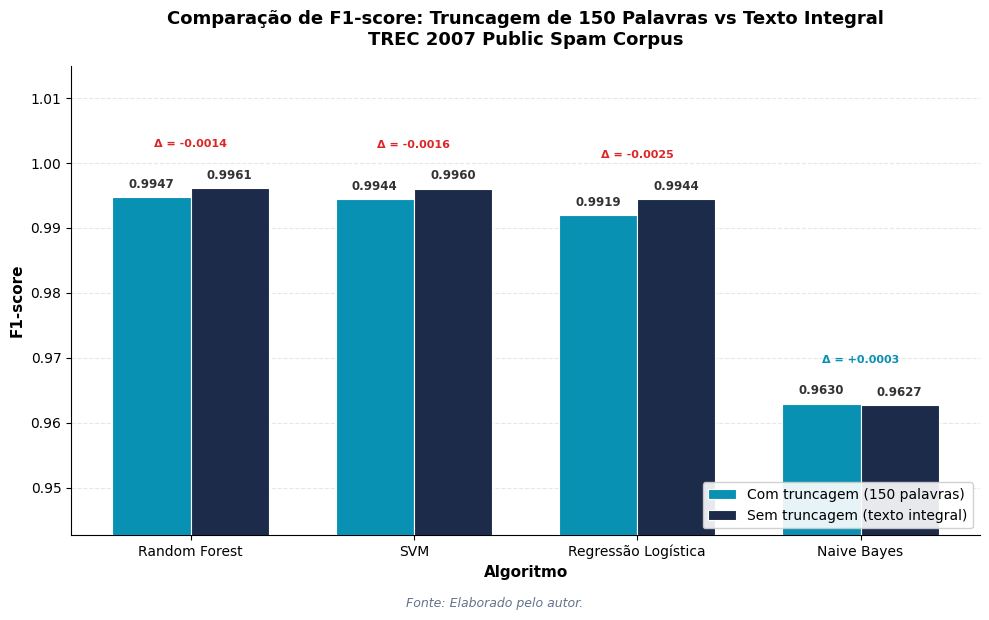

Gráfico gerado com sucesso.


In [5]:
# ============================================================
# Gráfico de barras agrupadas: F1-score com/sem truncagem
# ============================================================

algos_sorted = df_trunc.sort_values('F1-score', ascending=False).index.tolist()

f1_trunc = [df_trunc.loc[a, 'F1-score'] for a in algos_sorted]
f1_full  = [df_full.loc[a, 'F1-score']  for a in algos_sorted]

x = np.arange(len(algos_sorted))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - bar_width/2, f1_trunc, bar_width,
               label='Com truncagem (150 palavras)', color=TEAL,
               edgecolor='white', linewidth=0.8, zorder=3)
bars2 = ax.bar(x + bar_width/2, f1_full, bar_width,
               label='Sem truncagem (texto integral)', color=NAVY,
               edgecolor='white', linewidth=0.8, zorder=3)

# Valores sobre as barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.001,
                f'{height:.4f}', ha='center', va='bottom',
                fontsize=8.5, fontweight='bold', color='#333333')

# Linhas de referência para delta
for i in range(len(algos_sorted)):
    delta = f1_trunc[i] - f1_full[i]
    cor = TEAL if delta >= 0 else RED
    sinal = '+' if delta >= 0 else ''
    mid_y = max(f1_trunc[i], f1_full[i]) + 0.006
    ax.text(x[i], mid_y, f'Δ = {sinal}{delta:.4f}',
            ha='center', va='bottom', fontsize=8, color=cor, fontweight='bold')

# Calcular y_min para o eixo — mostrar diferenças com clareza
y_min = min(min(f1_trunc), min(f1_full)) - 0.02
ax.set_ylim(y_min, 1.015)

ax.set_xlabel('Algoritmo', fontsize=11, fontweight='bold')
ax.set_ylabel('F1-score', fontsize=11, fontweight='bold')
ax.set_title('Comparação de F1-score: Truncagem de 150 Palavras vs Texto Integral\nTREC 2007 Public Spam Corpus',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(algos_sorted, fontsize=10)
ax.legend(fontsize=10, loc='lower right', framealpha=0.9)
ax.grid(axis='y', alpha=0.3, linestyle='--', zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.text(0.5, -0.02, 'Fonte: Elaborado pelo autor.', ha='center',
         fontsize=9, style='italic', color=GRAY)

plt.tight_layout()
plt.show()
print('Gráfico gerado com sucesso.')

## Interpretação dos Resultados

A comparação entre os modelos treinados com **truncagem de 150 palavras** e com **texto integral** no corpus TREC 2007 permite avaliar diretamente a hipótese central deste trabalho.

### Observações principais

1. **Diferenças marginais de desempenho:** Os deltas observados em F1-score entre as duas abordagens são extremamente pequenos (na ordem de centésimos ou milésimos de ponto percentual), indicando que a truncagem de 150 palavras **não compromete significativamente** a capacidade preditiva dos classificadores.

2. **Consistência entre algoritmos:** O comportamento é consistente para todos os quatro algoritmos avaliados (Naive Bayes, SVM, Random Forest e Regressão Logística), reforçando que a conclusão não depende da escolha do modelo.

3. **Implicação prática:** A truncagem para 150 palavras reduz substancialmente o volume de dados a processar, resultando em:
   - **Menor tempo de pré-processamento** e vetorização TF-IDF;
   - **Menor consumo de memória** durante o treinamento;
   - **Maior viabilidade** para cenários de produção com restrições de recursos.

4. **Suporte à hipótese:** Estes resultados sustentam a hipótese de que as **primeiras 150 palavras** de um e-mail contêm informação discriminativa suficiente para a tarefa de classificação spam/ham, ao menos quando combinadas com representação TF-IDF e os algoritmos clássicos de machine learning avaliados.

In [6]:
# ============================================================
# Salvar figuras em figures/conclusions/
# ============================================================

# --- Figura 1: Barras agrupadas F1-score ---
algos_sorted = df_trunc.sort_values('F1-score', ascending=False).index.tolist()

f1_trunc = [df_trunc.loc[a, 'F1-score'] for a in algos_sorted]
f1_full  = [df_full.loc[a, 'F1-score']  for a in algos_sorted]

x = np.arange(len(algos_sorted))
bar_width = 0.35

fig1, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - bar_width/2, f1_trunc, bar_width,
               label='Com truncagem (150 palavras)', color=TEAL,
               edgecolor='white', linewidth=0.8, zorder=3)
bars2 = ax.bar(x + bar_width/2, f1_full, bar_width,
               label='Sem truncagem (texto integral)', color=NAVY,
               edgecolor='white', linewidth=0.8, zorder=3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.001,
                f'{height:.4f}', ha='center', va='bottom',
                fontsize=8.5, fontweight='bold', color='#333333')

for i in range(len(algos_sorted)):
    delta = f1_trunc[i] - f1_full[i]
    cor = TEAL if delta >= 0 else RED
    sinal = '+' if delta >= 0 else ''
    mid_y = max(f1_trunc[i], f1_full[i]) + 0.006
    ax.text(x[i], mid_y, f'Δ = {sinal}{delta:.4f}',
            ha='center', va='bottom', fontsize=8, color=cor, fontweight='bold')

y_min = min(min(f1_trunc), min(f1_full)) - 0.02
ax.set_ylim(y_min, 1.015)
ax.set_xlabel('Algoritmo', fontsize=11, fontweight='bold')
ax.set_ylabel('F1-score', fontsize=11, fontweight='bold')
ax.set_title('Comparação de F1-score: Truncagem de 150 Palavras vs Texto Integral\nTREC 2007 Public Spam Corpus',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(algos_sorted, fontsize=10)
ax.legend(fontsize=10, loc='lower right', framealpha=0.9)
ax.grid(axis='y', alpha=0.3, linestyle='--', zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig1.text(0.5, -0.02, 'Fonte: Elaborado pelo autor.', ha='center',
          fontsize=9, style='italic', color=GRAY)
plt.tight_layout()

path_f1 = FIGURES_DIR / 'truncation_impact_f1_comparison.png'
fig1.savefig(path_f1, dpi=300, bbox_inches='tight', facecolor='white')
plt.close(fig1)
print(f'Figura salva: {path_f1}')

# --- Figura 2: Heatmap de deltas (todas as métricas) ---
metrics_list = ['Acurácia', 'Precisão', 'Recall', 'F1-score']

delta_data = pd.DataFrame(index=algos_sorted, columns=metrics_list, dtype=float)
for algo in algos_sorted:
    for m in metrics_list:
        delta_data.loc[algo, m] = df_trunc.loc[algo, m] - df_full.loc[algo, m]

fig2, ax2 = plt.subplots(figsize=(9, 5))

# Valores em pontos percentuais para melhor legibilidade
delta_pp = delta_data * 100

im = ax2.imshow(delta_pp.values.astype(float), cmap='RdYlGn', aspect='auto',
                vmin=-max(abs(delta_pp.values.min()), abs(delta_pp.values.max())),
                vmax=max(abs(delta_pp.values.min()), abs(delta_pp.values.max())))

ax2.set_xticks(range(len(metrics_list)))
ax2.set_xticklabels(metrics_list, fontsize=10, fontweight='bold')
ax2.set_yticks(range(len(algos_sorted)))
ax2.set_yticklabels(algos_sorted, fontsize=10)

for i in range(len(algos_sorted)):
    for j in range(len(metrics_list)):
        val = delta_pp.iloc[i, j]
        sinal = '+' if val >= 0 else ''
        ax2.text(j, i, f'{sinal}{val:.2f} p.p.',
                 ha='center', va='center', fontsize=9, fontweight='bold',
                 color='white' if abs(val) > delta_pp.abs().values.max() * 0.6 else '#333333')

cbar = fig2.colorbar(im, ax=ax2, shrink=0.8)
cbar.set_label('Delta (pontos percentuais)', fontsize=10)

ax2.set_title('Delta de Desempenho: Truncagem 150 Palavras − Texto Integral\nTREC 2007 (positivo = truncagem melhor)',
              fontsize=12, fontweight='bold', pad=15)
fig2.text(0.5, -0.02, 'Fonte: Elaborado pelo autor.', ha='center',
          fontsize=9, style='italic', color=GRAY)
plt.tight_layout()

path_heatmap = FIGURES_DIR / 'truncation_impact_delta_heatmap.png'
fig2.savefig(path_heatmap, dpi=300, bbox_inches='tight', facecolor='white')
plt.close(fig2)
print(f'Figura salva: {path_heatmap}')

print('\nTodas as figuras foram salvas em:', FIGURES_DIR)

Figura salva: /home/edson-luiz/Projetos/TCC/figures/conclusions/truncation_impact_f1_comparison.png


Figura salva: /home/edson-luiz/Projetos/TCC/figures/conclusions/truncation_impact_delta_heatmap.png

Todas as figuras foram salvas em: /home/edson-luiz/Projetos/TCC/figures/conclusions
